# Forecasting Healthcare Call Demand Under Structural Breaks – Data Wrangling and EDA Notebook
**Author:** Allison M. Schiltz

---

##  Project Overview
- **Problem:** Predict monthly healthcare call demand in Bangladesh and quantify forecast accuracy under structural breaks caused by major public health emergencies.

- **Dataset:** The ["Healthcare Call Data Analysis During Emergency Times"](https://www.kaggle.com/datasets/shuvokumarbasak2030/healthcare-call-data-analysis-duringemergencytimes) dataset (Kaggle), sourced from the [Health Portal Dashboard](https://16263.dghs.gov.bd/report/report.php) operated by the Bangladesh government which spans 2016–2025 and includes multiple distinct emergency events.


## 0. Environment & Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import numpy as np
from importlib.metadata import version
import sys

packages = ["pandas", "matplotlib", "seaborn", "statsmodels", "numpy"]
for p in packages:
    print(f"{p}: {version(p)}")

print(f"Environment: {sys.version}")

pandas: 2.3.3
matplotlib: 3.10.7
seaborn: 0.13.2
statsmodels: 0.14.4
numpy: 2.3.4
Environment: 3.11.9 (main, Jun  5 2025, 11:28:29) [Clang 17.0.0 (clang-1700.0.13.5)]


## 1. Load Raw Data

In [3]:
# Load the data
df_raw = pd.read_csv('../data/raw/daily_and_month_call_report.csv')

## 2. Initial Inspection

In [4]:
print('HEAD:\n', df_raw.head())
print('\nTAIL:\n', df_raw.tail())
print('\nSAMPLE:\n', df_raw.sample(n=5, random_state=42))
print('\nSHAPE:\n', df_raw.shape)
print('\nINFO:')
df_raw.info()
print('\nDESCRIBE:\n', df_raw.describe().T)
print('\nNULL COUNTS:\n', df_raw.isnull().sum().sort_values(ascending=False))

HEAD:
    Year Month  Total Number of Calls  Total Number of Doctors Consultancy  \
0  2025   Feb                 155200                                98964   
1  2025   Jan                 130982                                87815   
2  2024   Dec                 133725                                86832   
3  2024   Nov                 153698                                93710   
4  2024   Oct                 214604                               108207   

   Number of Total Health Information  Number of Total Ambulance Information  \
0                                3777                                   5773   
1                                3217                                   4179   
2                                3634                                   3735   
3                                3010                                   4421   
4                                6307                                   5792   

   Number of Total Complaints  Number of Calls To

## 3. Draft Data Dictionary (from raw)

In [5]:
# Build a  data dictionary for the raw dataset
data_dictionary = pd.DataFrame([
    {
        "raw_column": "Year",
        "description": "Calendar year of the observation.",
        "example_or_unit": "2019"
    },
    {
        "raw_column": "Month",
        "description": "Month label used with Year to form the monthly date.",
        "example_or_unit": "Jan, Feb, ..."
    },
    {
        "raw_column": "Total Number of Calls",
        "description": "Total inbound calls received by the healthcare service.",
        "example_or_unit": "Count of calls"
    },
    {
        "raw_column": "Total Number of Doctors Consultancy",
        "description": "Calls that resulted in doctor consultation.",
        "example_or_unit": "Count of consult calls"
    },
    {
        "raw_column": "Number of Total Health Information",
        "description": "Calls requesting general health information.",
        "example_or_unit": "Count of information calls"
    },
    {
        "raw_column": "Number of Total Ambulance Information",
        "description": "Calls requesting ambulance-related information.",
        "example_or_unit": "Count of information calls"
    },
    {
        "raw_column": "Number of Total Complaints",
        "description": "Calls logged as complaints (system strain proxy).",
        "example_or_unit": "Count of complaint calls"
    },
    {
        "raw_column": "Number of Calls To Know About The Service",
        "description": "Calls asking about available services.",
        "example_or_unit": "Count of service inquiry calls"
    }
])

data_dictionary["raw_dtype"] = data_dictionary["raw_column"].map(df_raw.dtypes.astype(str))
data_dictionary["unique_values"] = data_dictionary["raw_column"].map(df_raw.nunique(dropna=True))

display(data_dictionary[["raw_column", "raw_dtype", "unique_values", "description", "example_or_unit"]])

,raw_column,raw_dtype,unique_values,description,example_or_unit
0,Year,int64,10,Calendar year of the observation.,2019
1,Month,object,12,Month label used with Year to form the monthly...,"Jan, Feb, ..."
2,Total Number of Calls,int64,107,Total inbound calls received by the healthcare...,Count of calls
3,Total Number of Doctors Consultancy,int64,106,Calls that resulted in doctor consultation.,Count of consult calls
4,Number of Total Health Information,int64,107,Calls requesting general health information.,Count of information calls
5,Number of Total Ambulance Information,int64,107,Calls requesting ambulance-related information.,Count of information calls
6,Number of Total Complaints,int64,107,Calls logged as complaints (system strain proxy).,Count of complaint calls
7,Number of Calls To Know About The Service,int64,107,Calls asking about available services.,Count of service inquiry calls


## 4. Data Quality Audit

### 4.1 Missingness
- No missing data

In [6]:
# Check for missing values -- NaN or None
missing = pd.concat([df_raw.isnull().sum(), 100 * df_raw.isnull().mean()], axis=1)
missing.columns=['count', '%']
missing.sort_values(by='count', ascending=False)

,count,%
Year,0,0.0
Month,0,0.0
Total Number of Calls,0,0.0
Total Number of Doctors Consultancy,0,0.0
Number of Total Health Information,0,0.0
Number of Total Ambulance Information,0,0.0
Number of Total Complaints,0,0.0
Number of Calls To Know About The Service,0,0.0


In [7]:
# Check for blank or whitespace-only strings in object columns
for col in df_raw.select_dtypes(include='object'):
    n_blanks = (df_raw[col].str.strip() == '').sum()
    if n_blanks > 0:
        print(f"{col}: {n_blanks} blank/whitespace values")
    else:
        print(f"{col}: No blank/whitespace values")

Month: No blank/whitespace values


In [8]:
# Check for placeholder values
placeholders = ['NA', 'N/A', 'null', 'None', '?', '-']
for col in df_raw.columns:
    for val in placeholders:
        n = (df_raw[col] == val).sum()
        if n > 0:
            print(f"{col}: {n} occurrences of '{val}'")

In [9]:
# Check for constant columns
for col in df_raw.columns:
    if df_raw[col].nunique(dropna=False) == 1:
        print(f"{col} has only one unique value: {df_raw[col].unique()}")

### 4.2 Duplicates

In [10]:
# number unique values
df_raw.nunique()

Year                                          10
Month                                         12
Total Number of Calls                        107
Total Number of Doctors Consultancy          106
Number of Total Health Information           107
Number of Total Ambulance Information        107
Number of Total Complaints                   107
Number of Calls To Know About The Service    107
dtype: int64

In [11]:
# Find duplicate rows
duplicates = df_raw[df_raw.duplicated()]

# Display duplicate rows (if any)
print(duplicates)

# Count duplicate rows
print(df_raw.duplicated().sum())

Empty DataFrame
Columns: [Year, Month, Total Number of Calls, Total Number of Doctors Consultancy, Number of Total Health Information, Number of Total Ambulance Information, Number of Total Complaints, Number of Calls To Know About The Service]
Index: []
0


In [12]:
# View unique values per column
for col in df_raw.columns:
    if df_raw[col].nunique() < 13:
        print(df_raw[col].value_counts(), "\n")

Year
2024    12
2023    12
2019    12
2022    12
2021    12
2020    12
2017    12
2018    12
2016     9
2025     2
Name: count, dtype: int64 

Month
Feb     9
Jan     9
Dec     9
Nov     9
Oct     9
Sept    9
Aug     9
July    9
June    9
May     9
Apr     9
Mar     8
Name: count, dtype: int64 



### 4.3 Data Types and Conversion

In [13]:
# Standardize month names
month_map = {
    "jan": "Jan", "january": "Jan",
    "feb": "Feb", "february": "Feb",
    "mar": "Mar", "march": "Mar",
    "apr": "Apr", "april": "Apr",
    "may": "May",
    "jun": "Jun", "june": "Jun",
    "jul": "Jul", "july": "Jul",
    "aug": "Aug", "august": "Aug",
    "sep": "Sep", "sept": "Sep", "september": "Sep",
    "oct": "Oct", "october": "Oct",
    "nov": "Nov", "november": "Nov",
    "dec": "Dec", "december": "Dec",
}

m = (
    df_raw["Month"]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(".", "", regex=False)
)

df_raw["Month"] = m.map(month_map)

# Validate: fail fast if any month didn't map
if df_raw["Month"].isna().any():
    bad = df_raw.loc[df_raw["Month"].isna(), "Month"]
    raise ValueError(f"Unmapped month values found: {bad.unique()}")


In [14]:
df_raw['Month'].unique()

array(['Feb', 'Jan', 'Dec', 'Nov', 'Oct', 'Sep', 'Aug', 'Jul', 'Jun',
       'May', 'Apr', 'Mar'], dtype=object)

In [15]:
# Create datetime object
df_raw["Date"] = pd.to_datetime(
    df_raw["Year"].astype(str) + "-" + df_raw["Month"],
    format="%Y-%b",
    errors="raise"
)

In [16]:
# Check data types 
print(df_raw.dtypes)

Year                                                  int64
Month                                                object
Total Number of Calls                                 int64
Total Number of Doctors Consultancy                   int64
Number of Total Health Information                    int64
Number of Total Ambulance Information                 int64
Number of Total Complaints                            int64
Number of Calls To Know About The Service             int64
Date                                         datetime64[ns]
dtype: object


In [17]:
# Set Date as index and sort oldest to newest
df_raw.set_index('Date', inplace=True)
df_raw.sort_index(inplace=True)

### 4.4 Numeric Ranges & Impossible Values

In [18]:
# 1) Numeric range (percentiles) — good for understanding bounds
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns
print("NUMERIC SUMMARY (extended percentiles)")
display(df_raw[numeric_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T)

# 2) Impossible values: negatives catch data entry errors
negatives_any = (df_raw[numeric_cols] < 0).any()
bad_negative_cols = negatives_any[negatives_any].index.tolist()
print("Numeric columns with any negative values:", bad_negative_cols if bad_negative_cols else "None")

NUMERIC SUMMARY (extended percentiles)


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Year,107.0,2020.205607,2.601662,2016.0,2016.00,2016.0,2018.0,2020.0,2022.0,2024.0,2024.94,2025.0
Total Number of Calls,107.0,234031.626168,369700.080656,51432.0,66093.62,73060.6,99188.5,142400.0,202552.0,486810.4,2018940.82,2329457.0
Total Number of Doctors Consultancy,107.0,154455.345794,268135.135666,38162.0,38598.42,47919.9,60818.0,94893.0,121526.5,296852.6,1518947.18,1703100.0
Number of Total Health Information,107.0,15714.728972,23104.165341,3010.0,3177.52,3936.9,6858.0,10841.0,13291.0,41286.8,108082.92,173306.0
Number of Total Ambulance Information,107.0,9240.317757,15330.680874,220.0,335.08,383.8,836.0,4734.0,8658.5,46649.2,63046.16,91751.0
Number of Total Complaints,107.0,6924.457944,10484.201602,77.0,295.98,362.5,697.0,4133.0,8262.0,24394.2,49833.52,59760.0
Number of Calls To Know About The Service,107.0,47509.102804,61227.797516,4075.0,9222.10,11099.1,18536.5,28895.0,45822.5,150202.2,317248.08,342434.0


Numeric columns with any negative values: None


In [19]:
# 3) Temporal continuity: check for gaps in the time series
expected_dates = pd.date_range(start=df_raw.index.min(), end=df_raw.index.max(), freq='MS')
missing_dates = expected_dates.difference(df_raw.index)
print(f"\nTemporal continuity: {len(missing_dates)} missing months")
if len(missing_dates) > 0:
    print("Missing dates (first 10):")
    print(missing_dates.tolist()[:10])


Temporal continuity: 0 missing months


In [20]:
# 4) Logical consistency: do call components make sense relative to total?
components = ['Total Number of Doctors Consultancy',
       'Number of Total Health Information',
       'Number of Total Ambulance Information', 'Number of Total Complaints',
       'Number of Calls To Know About The Service']
df_raw['sum_components'] = df_raw[components].sum(axis=1)

inconsistent = df_raw[df_raw['sum_components'] > df_raw['Total Number of Calls']]
print(f"\nLogical consistency: {len(inconsistent)} rows where component sums exceed total_calls")
if len(inconsistent) > 0:
    print("Rows with component sum > total:")
    display(inconsistent[['total_calls', 'sum_components'] + components])

# Clean up temporary column
df_raw.drop(columns=['sum_components'], inplace=True)


Logical consistency: 0 rows where component sums exceed total_calls


## 5. Data Cleaning & Transformation

In [21]:
# Drop redundant columns and rename columns for clarity
df = df_raw.copy()
df.drop(columns=['Year', 'Month'], inplace=True)
df.rename(columns={
    'Total Number of Calls': 'total_calls',
    'Total Number of Doctors Consultancy': 'total_doctor_consults',
    'Number of Total Health Information': 'health_info',
    'Number of Total Ambulance Information': 'ambulance_info',
    'Number of Total Complaints': 'complaints',
    'Number of Calls To Know About The Service': 'service_info'
}, inplace=True)

print("Cleaned dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst few rows:")
df.head()

Cleaned dataset shape: (107, 6)

Column names:
['total_calls', 'total_doctor_consults', 'health_info', 'ambulance_info', 'complaints', 'service_info']

First few rows:


,total_calls,total_doctor_consults,health_info,ambulance_info,complaints,service_info
Date,,,,,,
2016-04-01,51432,43885,3175,220,77,4075
2016-05-01,166635,137326,12118,925,439,15827
2016-06-01,186433,152580,14887,856,473,17637
2016-07-01,145061,116686,11831,922,404,15218
2016-08-01,142400,112831,12184,980,340,16065


## 6. Post-Cleaning Validation and Export

In [22]:
# Rerun data quality checks on cleaned dataset
print("\nDATA QUALITY CHECKS ON CLEANED DATASET")
print("\nSHAPE:\n", df.shape)
print('\nINFO:')
df.info()
print('\nNULL COUNTS:\n', df.isnull().sum().sort_values(ascending=False))   


DATA QUALITY CHECKS ON CLEANED DATASET

SHAPE:
 (107, 6)

INFO:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 107 entries, 2016-04-01 to 2025-02-01
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   total_calls            107 non-null    int64
 1   total_doctor_consults  107 non-null    int64
 2   health_info            107 non-null    int64
 3   ambulance_info         107 non-null    int64
 4   complaints             107 non-null    int64
 5   service_info           107 non-null    int64
dtypes: int64(6)
memory usage: 5.9 KB

NULL COUNTS:
 total_calls              0
total_doctor_consults    0
health_info              0
ambulance_info           0
complaints               0
service_info             0
dtype: int64


In [23]:
# Save cleaned dataset for next steps
df.to_csv('../data/processed/call_data_cleaned.csv', index=True)

In [24]:
# Build data dictionary for cleaned dataset
clean_data_dictionary = pd.DataFrame([
    {
        "clean_column": "total_calls",
        "description": "Total inbound calls received by the healthcare service.",
        "example_or_unit": "Count of calls"
    },
    {
        "clean_column": "total_doctor_consults",
        "description": "Calls that resulted in doctor consultation.",
        "example_or_unit": "Count of consult calls"
    },
    {
        "clean_column": "health_info",
        "description": "Calls requesting general health information.",
        "example_or_unit": "Count of information calls"
    },
    {
        "clean_column": "ambulance_info",
        "description": "Calls requesting ambulance-related information.",
        "example_or_unit": "Count of information calls"
    },
    {
        "clean_column": "complaints",
        "description": "Calls logged as complaints (system strain proxy).",
        "example_or_unit": "Count of complaint calls"
    },
    {
        "clean_column": "service_info",
        "description": "Calls asking about available services.",
        "example_or_unit": "Count of service inquiry calls"
    }
])

In [25]:
# Build metadata table
clean_dict_metadata = pd.DataFrame([
    {"meta_key": "dataset_name", "meta_value": "call_data_cleaned"},
    {"meta_key": "index_name", "meta_value": "Date"},
    {"meta_key": "index_dtype", "meta_value": str(df.index.dtype)},
    {"meta_key": "index_frequency_expected", "meta_value": "MS"},
    {"meta_key": "date_min", "meta_value": str(df.index.min().date())},
    {"meta_key": "date_max", "meta_value": str(df.index.max().date())},
    {"meta_key": "index_created_from", "meta_value": "Year + Month"},
])


In [26]:
# Save cleaned data dictionary and metadata
clean_data_dictionary.to_csv("../references/clean_data_dictionary.csv", index=False)
clean_dict_metadata.to_csv("../references/clean_data_dictionary_metadata.csv", index=False)

In [27]:
display(clean_dict_metadata)

,meta_key,meta_value
0,dataset_name,call_data_cleaned
1,index_name,Date
2,index_dtype,datetime64[ns]
3,index_frequency_expected,MS
4,date_min,2016-04-01
5,date_max,2025-02-01
6,index_created_from,Year + Month


## 7. Exploratory Data Analysis

### 7.1 Descriptive Statistics and Correlations

In [28]:
# Basic statistics on cleaned data
print("SUMMARY STATISTICS")
print(df.describe().T)

SUMMARY STATISTICS
                       count           mean            std      min      25%  \
total_calls            107.0  234031.626168  369700.080656  51432.0  99188.5   
total_doctor_consults  107.0  154455.345794  268135.135666  38162.0  60818.0   
health_info            107.0   15714.728972   23104.165341   3010.0   6858.0   
ambulance_info         107.0    9240.317757   15330.680874    220.0    836.0   
complaints             107.0    6924.457944   10484.201602     77.0    697.0   
service_info           107.0   47509.102804   61227.797516   4075.0  18536.5   

                            50%       75%        max  
total_calls            142400.0  202552.0  2329457.0  
total_doctor_consults   94893.0  121526.5  1703100.0  
health_info             10841.0   13291.0   173306.0  
ambulance_info           4734.0    8658.5    91751.0  
complaints               4133.0    8262.0    59760.0  
service_info            28895.0   45822.5   342434.0  


In [29]:
# Pairwise correlations
print("\nPAIRWISE CORRELATIONS")
corr_matrix = df.corr()
print(corr_matrix)


PAIRWISE CORRELATIONS
                       total_calls  total_doctor_consults  health_info  \
total_calls               1.000000               0.994481     0.924721   
total_doctor_consults     0.994481               1.000000     0.904190   
health_info               0.924721               0.904190     1.000000   
ambulance_info            0.891041               0.848324     0.820058   
complaints                0.871245               0.827180     0.836434   
service_info              0.962238               0.930864     0.899339   

                       ambulance_info  complaints  service_info  
total_calls                  0.891041    0.871245      0.962238  
total_doctor_consults        0.848324    0.827180      0.930864  
health_info                  0.820058    0.836434      0.899339  
ambulance_info               1.000000    0.933792      0.946049  
complaints                   0.933792    1.000000      0.917892  
service_info                 0.946049    0.917892      1.00000

### 7.2 Target Level and Volatility

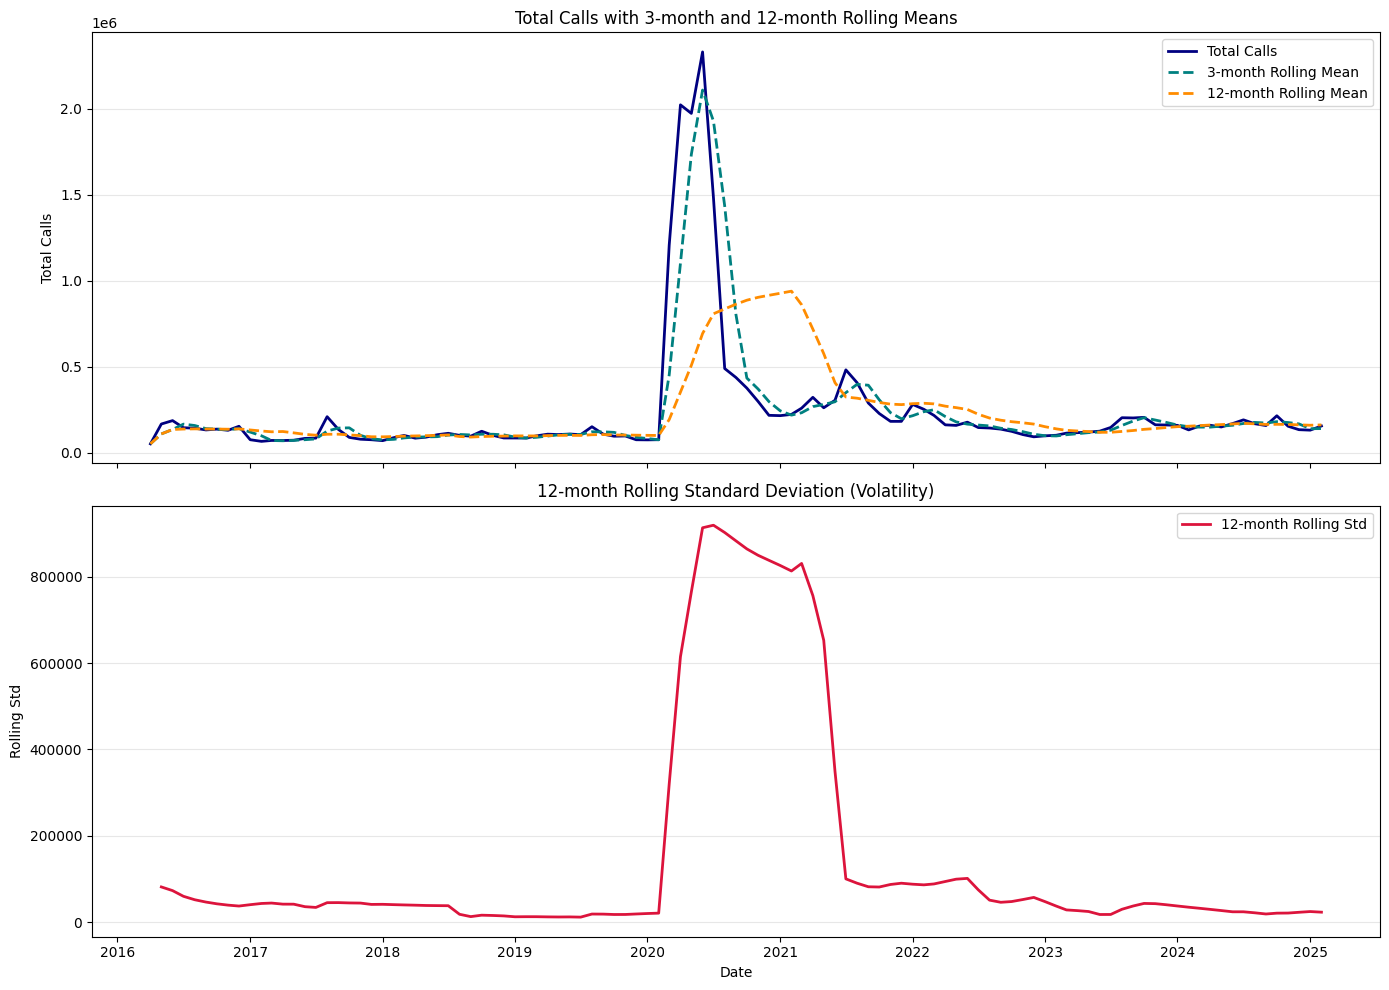

In [30]:
# 7.2 Target level and volatility
total_calls = df['total_calls'].astype(float).copy()
rolling_mean_3 = total_calls.rolling(window=3, min_periods=1).mean()
rolling_mean_12 = total_calls.rolling(window=12, min_periods=1).mean()
rolling_std_12 = total_calls.rolling(window=12, min_periods=2).std()
rolling_median = total_calls.rolling(window=3, min_periods=1).median()

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Time plot + rolling means
axes[0].plot(total_calls.index, total_calls, color='navy', linewidth=2, label='Total Calls')
axes[0].plot(rolling_mean_3.index, rolling_mean_3, color='teal', linewidth=2, linestyle='--', label='3-month Rolling Mean')
axes[0].plot(rolling_mean_12.index, rolling_mean_12, color='darkorange', linewidth=2, linestyle='--', label='12-month Rolling Mean')
axes[0].set_title('Total Calls with 3-month and 12-month Rolling Means')
axes[0].set_ylabel('Total Calls')
axes[0].grid(axis='y', alpha=0.3)
axes[0].legend()

# 12-month rolling volatility
axes[1].plot(rolling_std_12.index, rolling_std_12, color='crimson', linewidth=2, label='12-month Rolling Std')
axes[1].set_title('12-month Rolling Standard Deviation (Volatility)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Rolling Std')
axes[1].grid(axis='y', alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

### 7.3 Seasonality

/var/folders/xk/1_94y7fn37sf7kbch2g77hlm0000gp/T/ipykernel_32121/3489723575.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_season.groupby(['month_num', 'month_name'])['total_calls']


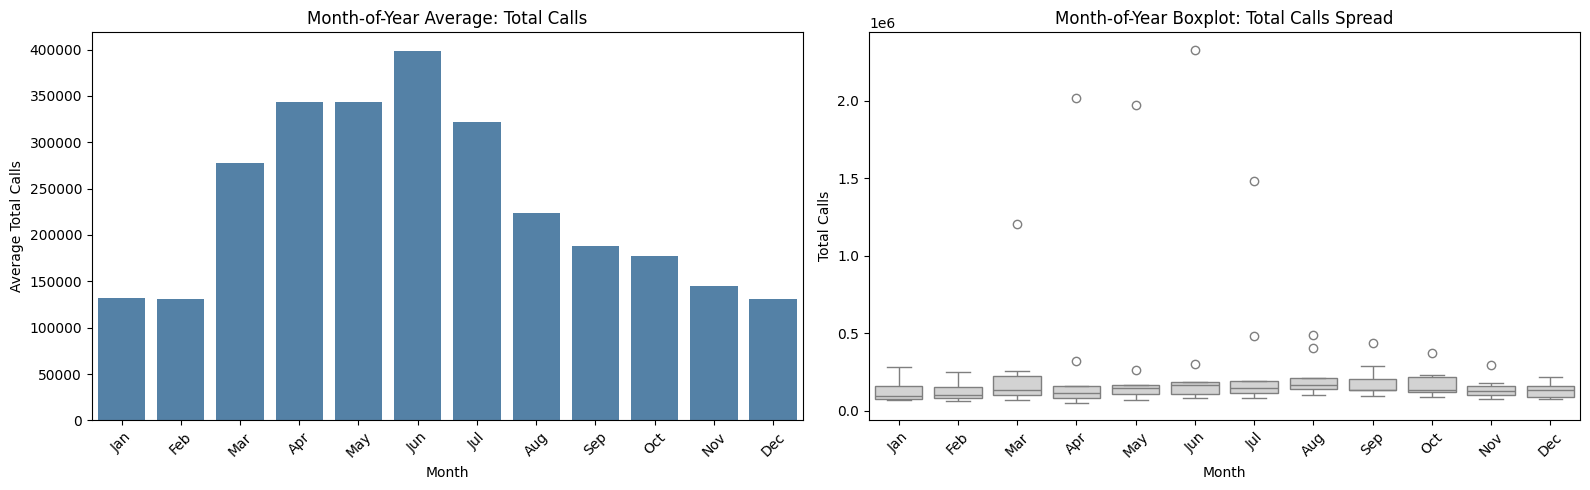

In [31]:
# Month-of-year seasonality diagnostics
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df_season = df[['total_calls']].copy()
df_season['month_num'] = df_season.index.month
df_season['month_name'] = pd.Categorical(df_season.index.strftime('%b'), categories=month_order, ordered=True)

month_avg = (
    df_season.groupby(['month_num', 'month_name'])['total_calls']
    .mean()
    .reset_index()
    .sort_values('month_num')
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=month_avg, x='month_name', y='total_calls', color='steelblue', ax=axes[0])
axes[0].set_title('Month-of-Year Average: Total Calls')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Average Total Calls')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df_season, x='month_name', y='total_calls', color='lightgray', ax=axes[1])
axes[1].set_title('Month-of-Year Boxplot: Total Calls Spread')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Total Calls')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 7.4 Regime Comparison (No Complaints)

In [32]:
# Regime comparison on total_calls only (excluding complaints by design)
pre_covid = df.loc[:'2020-02-01', 'total_calls'].dropna()
during_post_covid = df.loc['2020-03-01':, 'total_calls'].dropna()

regime_table = pd.DataFrame({
    'metric': ['mean', 'median', 'std', 'p95'],
    'pre_covid': [
        pre_covid.mean(),
        pre_covid.median(),
        pre_covid.std(),
        pre_covid.quantile(0.95),
    ],
    'during_post_covid': [
        during_post_covid.mean(),
        during_post_covid.median(),
        during_post_covid.std(),
        during_post_covid.quantile(0.95),
    ]
})
regime_table['change_pct'] = ((regime_table['during_post_covid'] - regime_table['pre_covid']) / regime_table['pre_covid']) * 100

variance_ratio = during_post_covid.var() / pre_covid.var()

print('REGIME COMPARISON: TOTAL_CALLS ONLY')
display(regime_table.set_index('metric').round(2))
print(f'Variance ratio (during/post over pre): {variance_ratio:.2f}')

REGIME COMPARISON: TOTAL_CALLS ONLY


,pre_covid,during_post_covid,change_pct
metric,,,
mean,103897.38,335970.12,223.37
median,97104.00,179709.00,85.07
std,33056.24,469731.09,1321.01
p95,162690.60,1506391.80,825.92


Variance ratio (during/post over pre): 201.93


### 7.5 Decomposition and Stationarity

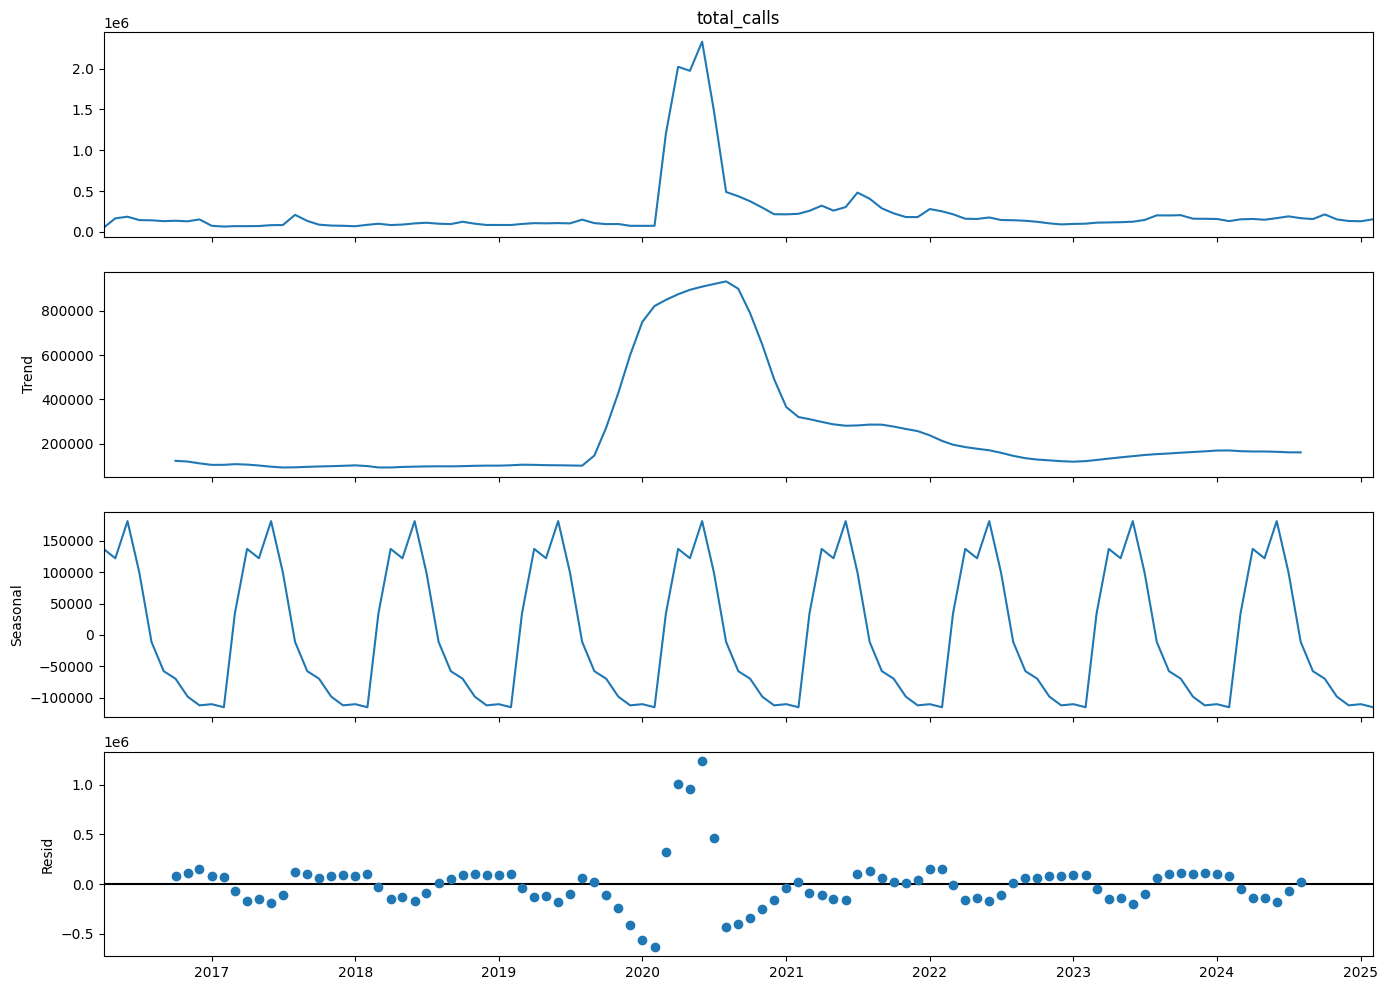

Raw total_calls:
  ADF statistic: -2.2352
  p-value      : 0.1937
  Critical (5%): -2.8915
  Stationary?  : No

Differenced total_calls:
  ADF statistic: -5.6686
  p-value      : 0.0000
  Critical (5%): -2.8915
  Stationary?  : Yes



In [33]:
# Seasonal decomposition of total_calls (monthly period = 12)
decomp = seasonal_decompose(total_calls, model='additive', period=12)
fig = decomp.plot()
fig.set_size_inches(14, 10)
plt.tight_layout()
plt.show()

# ADF tests on raw and first-differenced series
differenced_calls = total_calls.diff().dropna()

def adf_summary(series, label):
    adf_stat, p_value, _, _, critical_values, _ = adfuller(series)
    print(f'{label}:')
    print(f'  ADF statistic: {adf_stat:.4f}')
    print(f'  p-value      : {p_value:.4f}')
    print(f"  Critical (5%): {critical_values['5%']:.4f}")
    print('  Stationary?  :', 'Yes' if p_value < 0.05 else 'No')
    print('')

adf_summary(total_calls, 'Raw total_calls')
adf_summary(differenced_calls, 'Differenced total_calls')

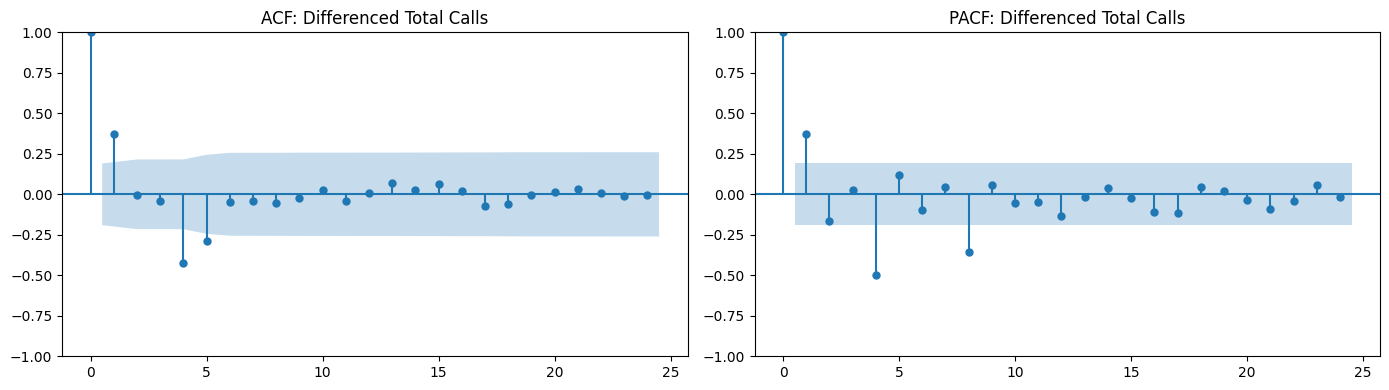

In [34]:
# ACF/PACF on differenced total_calls
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

max_lags = min(24, max(1, len(differenced_calls) // 2 - 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(differenced_calls, lags=max_lags, ax=axes[0])
axes[0].set_title('ACF: Differenced Total Calls')

plot_pacf(differenced_calls, lags=max_lags, ax=axes[1], method='ywm')
axes[1].set_title('PACF: Differenced Total Calls')

plt.tight_layout()
plt.show()

### 7.6 Forecast Baseline (Seasonal Naive)

SEASONAL NAIVE BASELINE (12-month holdout)
MAE : 31,354.17
RMSE: 33,714.22


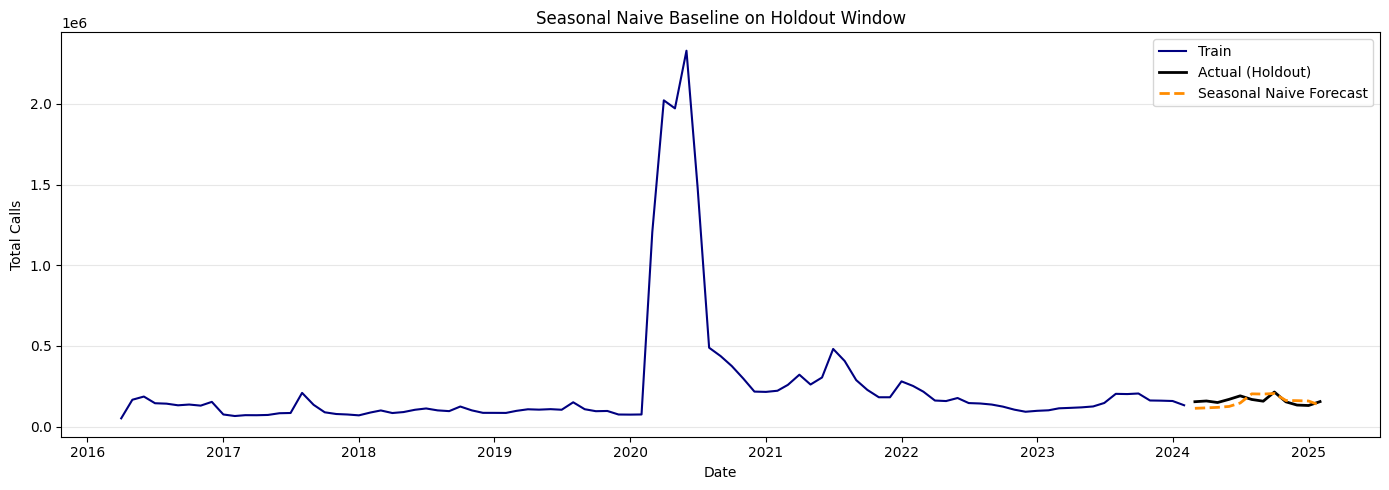

In [35]:
# Seasonal naive baseline using a 12-month holdout window
holdout_periods = 12
train = total_calls.iloc[:-holdout_periods]
test = total_calls.iloc[-holdout_periods:]

seasonal_naive_forecast = total_calls.shift(12).reindex(test.index)
eval_df = pd.DataFrame({
    'actual': test,
    'seasonal_naive': seasonal_naive_forecast
}).dropna()

mae = np.mean(np.abs(eval_df['actual'] - eval_df['seasonal_naive']))
rmse = np.sqrt(np.mean((eval_df['actual'] - eval_df['seasonal_naive']) ** 2))

print('SEASONAL NAIVE BASELINE (12-month holdout)')
print(f'MAE : {mae:,.2f}')
print(f'RMSE: {rmse:,.2f}')

plt.figure(figsize=(14, 5))
plt.plot(train.index, train, label='Train', color='navy')
plt.plot(test.index, test, label='Actual (Holdout)', color='black', linewidth=2)
plt.plot(eval_df.index, eval_df['seasonal_naive'], label='Seasonal Naive Forecast', color='darkorange', linestyle='--', linewidth=2)
plt.title('Seasonal Naive Baseline on Holdout Window')
plt.xlabel('Date')
plt.ylabel('Total Calls')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Identified Emergency Events & Periods

Emergency events are defined from external, documented sources rather than inferred from the data. This avoids circular reasoning when later testing whether call volume and complaints respond to these events.

**Sources used to define event windows:**
- **2019 Dengue Outbreak**: Bangladesh's DGHS reported its largest dengue burden on record in 2019, with cases rising sharply from July and peaking in August–September 2019. (Source: WHO Bangladesh / DGHS)
- **COVID-19 Wave 1**: First confirmed case in Bangladesh March 8, 2020 (WHO). National lockdown declared March 26, 2020. Cases declined through late 2020.
- **COVID-19 Delta Wave**: The Delta variant drove Bangladesh's most severe wave, with daily cases peaking in late July–August 2021. (Source: IEDCR Bangladesh / Our World in Data)

In [36]:
# Event windows are anchored to externally documented dates, not derived from this data.
# This is intentional: we want to test whether the data responds to known events,
# not define events by looking at the data first (which would be circular).

events = {
    # Bangladesh DGHS: dengue cases rose sharply from July 2019, peaked Aug-Sep, subsided by Nov
    ('2019-07-01', '2019-11-01'): 'Dengue Outbreak 2019',
    # WHO: first BD case Mar 8, 2020; national lockdown Mar 26, 2020; cases declined late 2020
    ('2020-03-01', '2020-12-01'): 'COVID-19 Wave 1',
    # IEDCR Bangladesh: Delta wave peaked Jul-Aug 2021
    ('2021-06-01', '2021-09-01'): 'COVID-19 Delta Wave',
}

print("EMERGENCY EVENTS (externally sourced)")
print("=" * 50)
for (start, end), label in events.items():
    event_data = df.loc[start:end, 'total_calls']
    avg_calls = event_data.mean()
    max_calls = event_data.max()
    baseline = df.loc[:'2019-06-01', 'total_calls'].mean()
    pct_above = (avg_calls - baseline) / baseline * 100
    print(f"\n{label} ({start} to {end})")
    print(f"  Average calls : {avg_calls:,.0f}")
    print(f"  Peak calls    : {max_calls:,.0f}")
    print(f"  vs. pre-event baseline: {pct_above:+.1f}%")
    print(f"  Duration      : {len(event_data)} months")


EMERGENCY EVENTS (externally sourced)

Dengue Outbreak 2019 (2019-07-01 to 2019-11-01)
  Average calls : 111,271
  Peak calls    : 150,908
  vs. pre-event baseline: +5.8%
  Duration      : 5 months

COVID-19 Wave 1 (2020-03-01 to 2020-12-01)
  Average calls : 1,082,837
  Peak calls    : 2,329,457
  vs. pre-event baseline: +929.6%
  Duration      : 10 months

COVID-19 Delta Wave (2021-06-01 to 2021-09-01)
  Average calls : 370,273
  Peak calls    : 481,426
  vs. pre-event baseline: +252.1%
  Duration      : 4 months


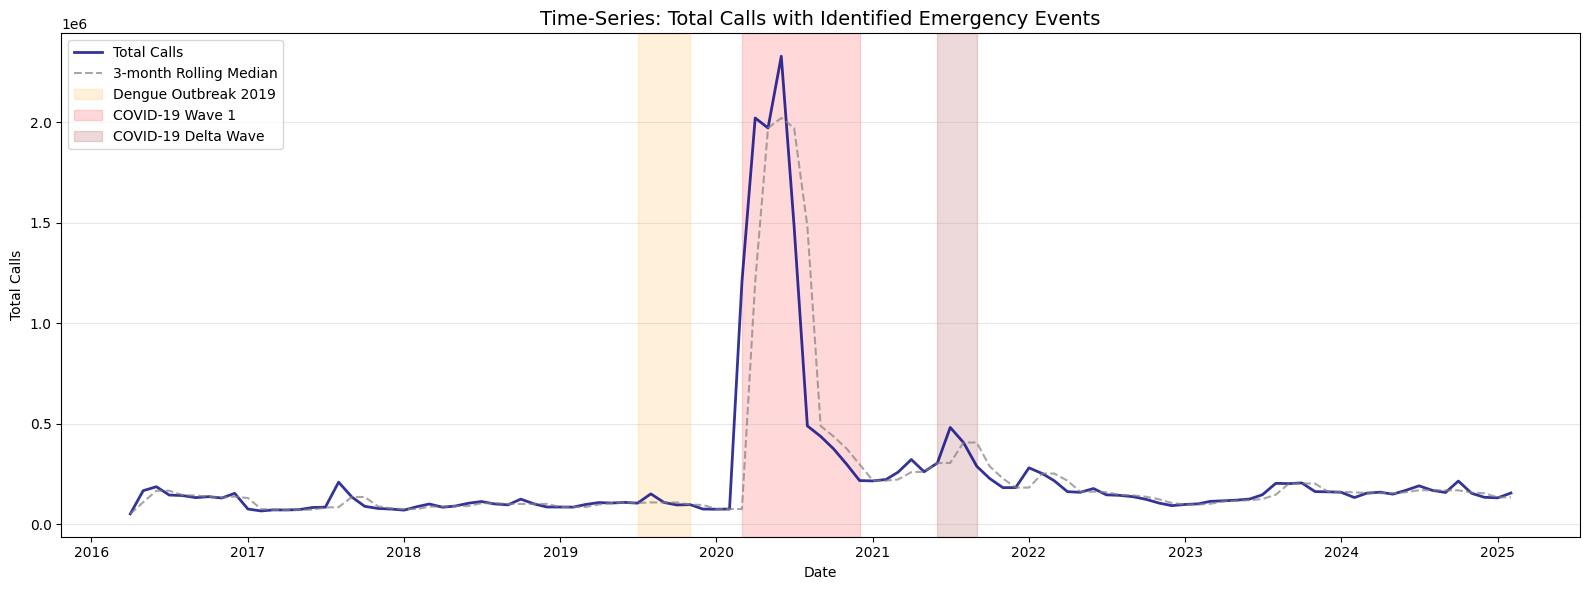


These events are candidates for detailed demand-strain analysis.


In [37]:
# Visualize time-series with annotated events
plt.figure(figsize=(16, 6))
plt.plot(df.index, df['total_calls'], linewidth=2, label='Total Calls', color='navy', alpha=0.8)
plt.plot(df.index, rolling_median, linewidth=1.5, linestyle='--', label='3-month Rolling Median', 
         color='gray', alpha=0.7)

# Color each event period differently
colors = ['orange', 'red', 'darkred']
for (start, end), label, color in zip(events.keys(), events.values(), colors):
    plt.axvspan(start, end, color=color, alpha=0.15, label=label)

plt.title('Time-Series: Total Calls with Identified Emergency Events', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Total Calls')
plt.legend(loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nThese events are candidates for detailed demand-strain analysis.")


In [38]:
# Check stationarity of the time series

def check_stationarity(series):
    result = adfuller(series)
    print(f'ADF Statistic: {result[0]:.3f}')
    print(f'p-value: {result[1]:.3f}')

check_stationarity(df['total_calls'])

ADF Statistic: -2.235
p-value: 0.194


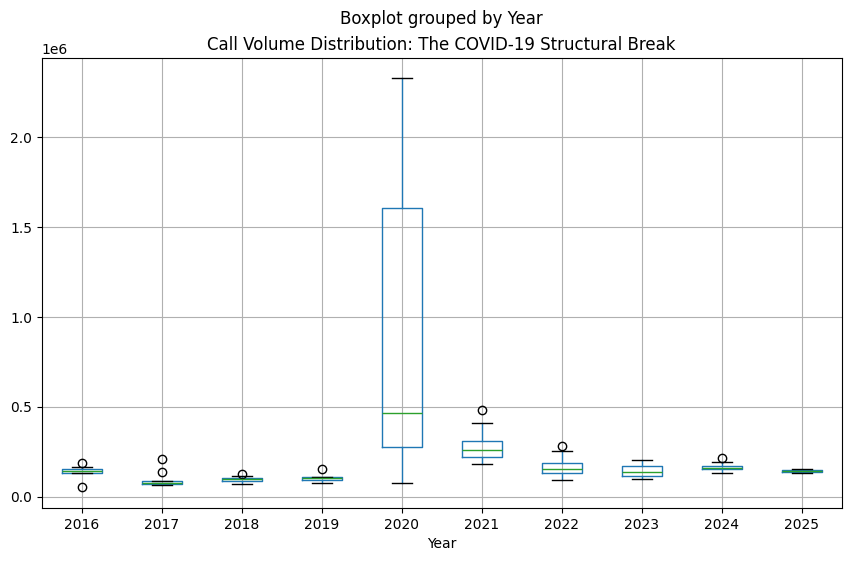

In [39]:
# Boxplot of call volume by year

df['Year'] = df.index.year
df.boxplot(column='total_calls', by='Year', figsize=(10,6))
plt.title('Call Volume Distribution: The COVID-19 Structural Break')
plt.show()

## 7. Forecasting Readiness Checklist

Use this checklist to confirm data wrangling and EDA are complete before model training.

### A. Data Wrangling Complete
- [ ] Monthly datetime index is created, sorted, and gap-checked.
- [ ] Column names are standardized for analysis (snake_case).
- [ ] Missingness, duplicates, and impossible values are documented.
- [ ] Logical consistency checks are completed (components vs total calls).
- [ ] Final clean dataset is saved to `data/processed/`.
- [ ] Clean data dictionary is saved to `references/`.

### B. EDA Complete (Model-Relevant)
- [ ] Target time-series (`total_calls`) is plotted with known event windows.
- [ ] Seasonality is described (monthly pattern and recurring peaks/troughs).
- [ ] Pre-COVID vs post-COVID summaries are reported.
- [ ] Structural break implications are explicitly stated.
- [ ] Candidate predictor behavior (`complaints`, consults, info calls) is summarized.

### C. Forecast Design Locked
- [ ] Target variable: `total_calls`.
- [ ] Forecast horizon: 1-month ahead (plus optional 3-month sensitivity).
- [ ] Split strategy: chronological only (no random split).
- [ ] Baseline model: seasonal naive.
- [ ] Candidate models: ETS and SARIMA/ARIMAX.
- [ ] Metrics: MAE and RMSE (MAPE if appropriate).

### D. Handoff to Modeling Notebook
- [ ] Final section states exact train/validation/test periods.
- [ ] Feature availability at prediction time is documented to prevent leakage.
- [ ] One-paragraph modeling plan is written for mentor review.

When all boxes above are checked, wrangling + EDA are complete and the project is ready for predictive modeling.